# Titanic — EDA, Pipeline de Classificação e Bônus de Regressão

**Objetivo:** prever a sobrevivência de passageiros do Titanic (classificação binária), com um pipeline de ML reproduzível de ponta a ponta — da análise exploratória à submissão no Kaggle. Ao final, um bônus aplica as técnicas típicas de **regressão com target assimétrico** (estilo *House Prices — Ames*) sobre a variável `Fare`.

**Dataset:** [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

## Dicionário de variáveis

| Variável | Descrição | Notas |
|---|---|---|
| `Survived` | Sobreviveu (0 = Não, 1 = Sim) | **Target** |
| `Pclass` | Classe do bilhete (1ª, 2ª, 3ª) | Proxy de status socioeconômico: 1ª = alta, 2ª = média, 3ª = baixa |
| `Name` | Nome do passageiro | Contém título (Mr., Mrs., Miss...) |
| `Sex` | Sexo | |
| `Age` | Idade em anos | Fracionária se < 1; estimada quando no formato `xx.5` |
| `SibSp` | Nº de irmãos/cônjuges a bordo | Irmão(ã), meio-irmão(ã), marido/esposa (amantes e noivos ignorados) |
| `Parch` | Nº de pais/filhos a bordo | Algumas crianças viajavam só com babá → `Parch = 0` |
| `Ticket` | Nº do bilhete | |
| `Fare` | Tarifa paga | |
| `Cabin` | Nº da cabine | ~77% ausente |
| `Embarked` | Porto de embarque | C = Cherbourg, Q = Queenstown, S = Southampton |

## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

In [2]:
# Funciona tanto com os CSVs ao lado do notebook quanto no sandbox
DATA_DIR = next((p for p in [Path('.'), Path('/mnt/user-data/uploads')]
                 if (p / 'train.csv').exists()), Path('.'))

train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Treino: {train.shape} | Teste: {test.shape}')
train.head()

Treino: (891, 12) | Teste: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Análise Exploratória (EDA)

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
# Valores ausentes
faltantes = (
    train.isnull().sum().to_frame('n_ausentes')
    .assign(pct=lambda d: (d['n_ausentes'] / len(train) * 100).round(1))
    .query('n_ausentes > 0')
    .sort_values('pct', ascending=False)
)
faltantes

,n_ausentes,pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


Três colunas têm ausências: `Cabin` (77% — demais para imputar diretamente, mas o **fato de ter cabine registrada** carrega sinal), `Age` (~20% — imputável) e `Embarked` (2 registros). A estratégia de tratamento fica centralizada no pipeline da seção 4, evitando vazamento de dados (*data leakage*): as estatísticas de imputação são aprendidas **apenas no treino** de cada fold.

/tmp/ipykernel_567/1103522968.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Não sobreviveu', 'Sobreviveu'])


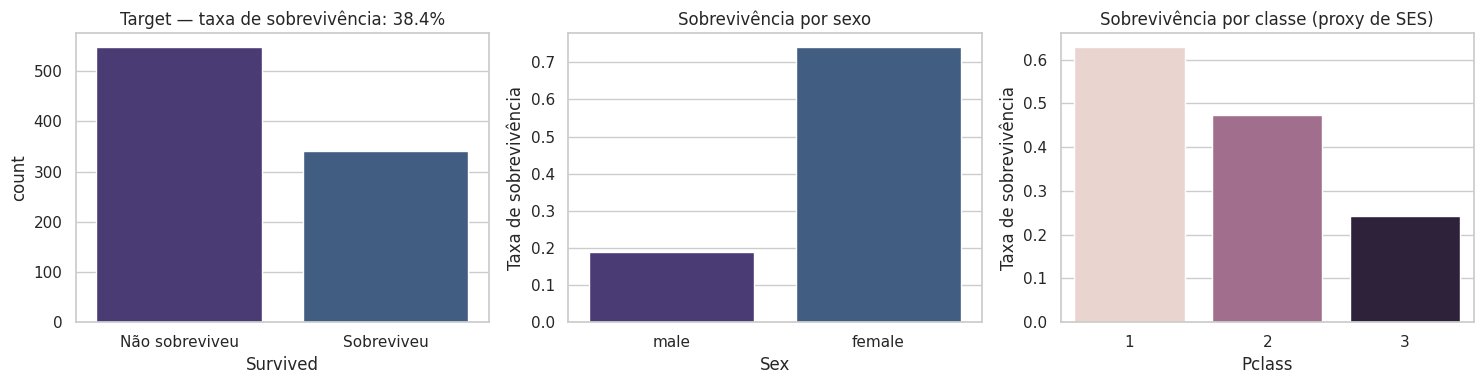

In [5]:
# Balanceamento do target
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=train, x='Survived', ax=axes[0], hue='Survived', legend=False)
axes[0].set_title(f'Target — taxa de sobrevivência: {train.Survived.mean():.1%}')
axes[0].set_xticklabels(['Não sobreviveu', 'Sobreviveu'])

sns.barplot(data=train, x='Sex', y='Survived', ax=axes[1], errorbar=None, hue='Sex', legend=False)
axes[1].set_title('Sobrevivência por sexo')
axes[1].set_ylabel('Taxa de sobrevivência')

sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[2], errorbar=None, hue='Pclass', legend=False)
axes[2].set_title('Sobrevivência por classe (proxy de SES)')
axes[2].set_ylabel('Taxa de sobrevivência')

plt.tight_layout()
plt.show()

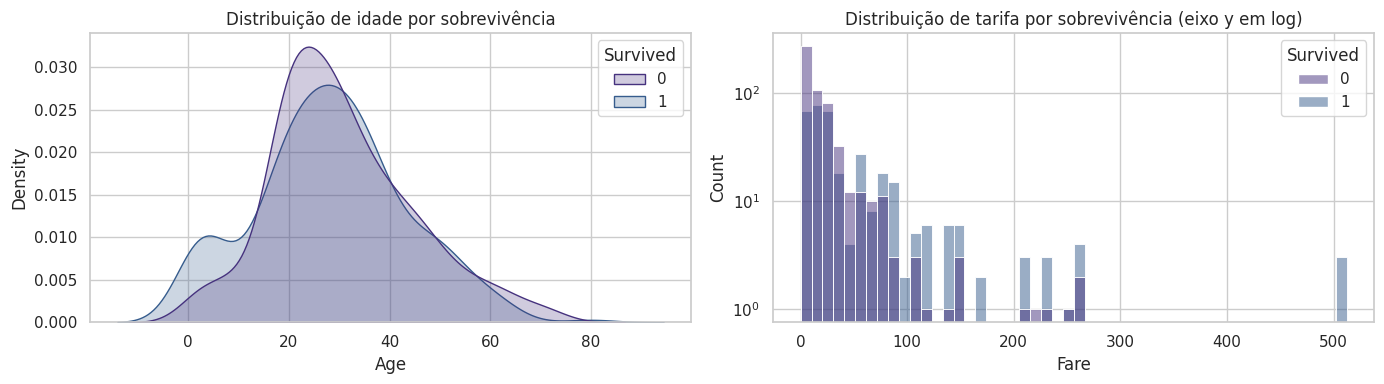

In [6]:
# Distribuições numéricas vs. target
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.kdeplot(data=train, x='Age', hue='Survived', fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Distribuição de idade por sobrevivência')

sns.histplot(data=train, x='Fare', hue='Survived', bins=50, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Distribuição de tarifa por sobrevivência (eixo y em log)')

plt.tight_layout()
plt.show()

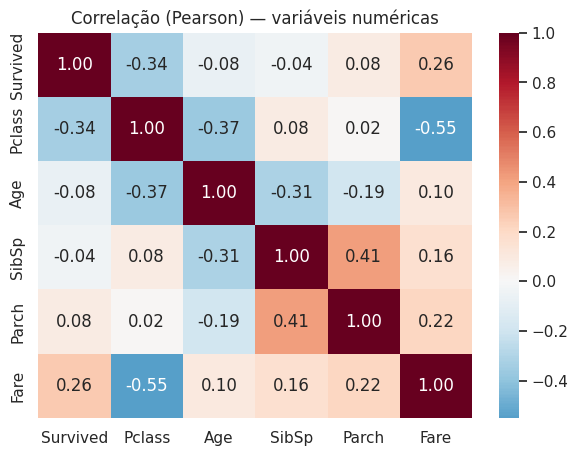

In [7]:
# Correlação entre variáveis numéricas
corr = train[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlação (Pearson) — variáveis numéricas')
plt.show()

**Achados da EDA:**

1. **Sexo é o preditor mais forte:** ~74% das mulheres sobreviveram vs. ~19% dos homens ("mulheres e crianças primeiro").
2. **Classe importa:** 1ª classe sobreviveu ~63% vs. ~24% na 3ª — consistente com `Pclass` como proxy socioeconômico e com a correlação negativa `Pclass`×`Survived` (-0.34).
3. **Idade:** crianças pequenas têm densidade maior entre sobreviventes; adultos jovens concentram os óbitos.
4. **Tarifa** correlaciona positivamente com sobrevivência (+0.26), em parte redundante com a classe.

## 3. Feature Engineering

Três famílias de variáveis derivadas, aplicadas de forma idêntica a treino e teste:

- **`Title`** — título extraído de `Name` (Mr, Mrs, Miss, Master...). Captura sexo, idade aproximada e status social num só atributo; títulos raros são agrupados.
- **`FamilySize` / `IsAlone`** — tamanho da família a bordo (`SibSp + Parch + 1`) e indicador de viajante solitário.
- **`Deck`** — primeira letra de `Cabin` (`U` = desconhecida). Transforma os 77% de ausência em categoria informativa.

In [8]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Título a partir do nome
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')[0].str.strip()
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
    principais = ['Mr', 'Mrs', 'Miss', 'Master']
    df['Title'] = df['Title'].where(df['Title'].isin(principais), 'Raro')

    # Estrutura familiar
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Deck da cabine
    df['Deck'] = df['Cabin'].str[0].fillna('U')

    return df

train_fe = engineer(train)
test_fe = engineer(test)

pd.crosstab(train_fe['Title'], train_fe['Survived'], normalize='index').round(2)

Survived,0,1
Title,,
Master,0.42,0.57
Miss,0.30,0.70
Mr,0.84,0.16
Mrs,0.21,0.79
Raro,0.65,0.35


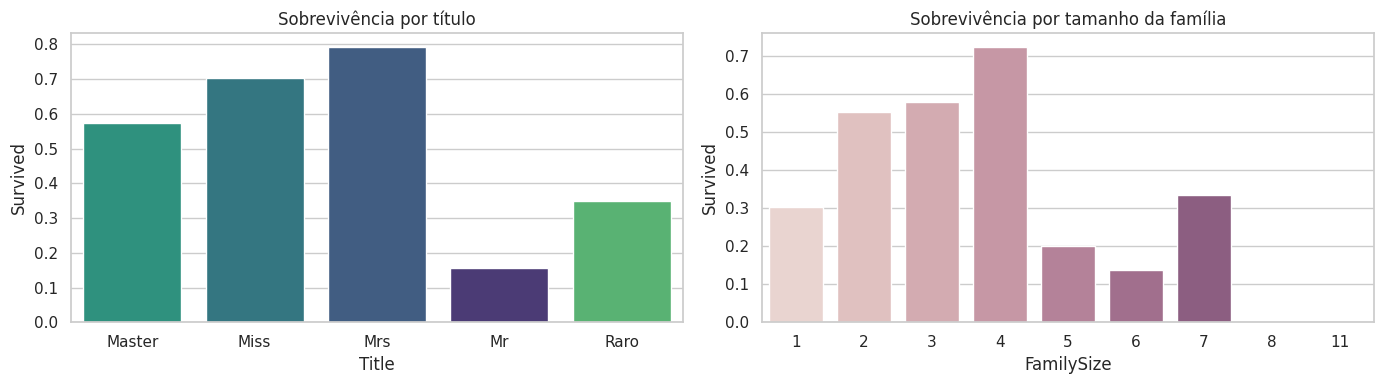

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=train_fe, x='Title', y='Survived', errorbar=None, ax=axes[0],
            order=['Master', 'Miss', 'Mrs', 'Mr', 'Raro'], hue='Title', legend=False)
axes[0].set_title('Sobrevivência por título')

sns.barplot(data=train_fe, x='FamilySize', y='Survived', errorbar=None, ax=axes[1],
            hue='FamilySize', legend=False)
axes[1].set_title('Sobrevivência por tamanho da família')

plt.tight_layout()
plt.show()

`Title` separa bem os grupos (Mrs/Miss ≈ 70–80% vs. Mr ≈ 16%), e `FamilySize` revela padrão não linear: famílias de 2–4 pessoas sobrevivem mais que solitários e que famílias grandes (5+) — informação que `SibSp`/`Parch` isolados não capturam.

## 4. Pipeline de Pré-processamento e Comparação de Modelos

Todo o pré-processamento vive dentro de um `Pipeline` do scikit-learn:

- **Numéricas** → imputação pela mediana + padronização (`StandardScaler`);
- **Categóricas** → imputação pela moda + `OneHotEncoder(handle_unknown='ignore')`.

Isso garante que a validação cruzada seja honesta (sem vazamento) e que o modelo final seja um único objeto serializável.

Metodologia: separo **20% como holdout** intocado; comparação de modelos e tuning acontecem só nos 80% restantes, com validação cruzada estratificada de 5 folds.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

FEATURES_NUM = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']
FEATURES_CAT = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck']
FEATURES = FEATURES_NUM + FEATURES_CAT

X = train_fe[FEATURES]
y = train_fe['Survived']

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preproc = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), FEATURES_NUM),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), FEATURES_CAT),
])

modelos = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'Hist. Gradient Boosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
for nome, clf in modelos.items():
    pipe = Pipeline([('preproc', preproc), ('clf', clf)])
    cv = cross_validate(pipe, X_tr, y_tr, cv=skf, scoring=['accuracy', 'f1'], n_jobs=-1)
    resultados.append({
        'Modelo': nome,
        'Acurácia (CV)': cv['test_accuracy'].mean(),
        '± std': cv['test_accuracy'].std(),
        'F1 (CV)': cv['test_f1'].mean(),
    })

resultados = pd.DataFrame(resultados).sort_values('Acurácia (CV)', ascending=False).reset_index(drop=True)
resultados.style.format({'Acurácia (CV)': '{:.4f}', '± std': '{:.4f}', 'F1 (CV)': '{:.4f}'})

,Modelo,Acurácia (CV),± std,F1 (CV)
0,Regressão Logística,0.8245,0.0249,0.7685
1,Gradient Boosting,0.8188,0.0227,0.7502
2,Hist. Gradient Boosting,0.8160,0.0242,0.7491
3,Random Forest,0.8146,0.0122,0.7554


## 5. Tuning do melhor modelo (`GridSearchCV`)

In [11]:
from sklearn.model_selection import GridSearchCV

grids = {
    'Regressão Logística': {'clf__C': [0.1, 1, 10]},
    'Random Forest': {'clf__n_estimators': [300, 500],
                      'clf__max_depth': [5, 8, None],
                      'clf__min_samples_leaf': [1, 3]},
    'Gradient Boosting': {'clf__n_estimators': [200, 400],
                          'clf__learning_rate': [0.05, 0.1],
                          'clf__max_depth': [2, 3]},
    'Hist. Gradient Boosting': {'clf__learning_rate': [0.05, 0.1],
                                'clf__max_depth': [3, None],
                                'clf__max_leaf_nodes': [15, 31]},
}

melhor_nome = resultados.iloc[0]['Modelo']
pipe_base = Pipeline([('preproc', preproc), ('clf', modelos[melhor_nome])])

grid = GridSearchCV(pipe_base, grids[melhor_nome], cv=skf, scoring='accuracy', n_jobs=-1)
grid.fit(X_tr, y_tr)

print(f'Melhor modelo: {melhor_nome}')
print(f'Melhores hiperparâmetros: {grid.best_params_}')
print(f'Acurácia (CV) após tuning: {grid.best_score_:.4f}')

Melhor modelo: Regressão Logística
Melhores hiperparâmetros: {'clf__C': 1}
Acurácia (CV) após tuning: 0.8245


## 6. Avaliação no holdout

                precision    recall  f1-score   support

Não sobreviveu       0.85      0.90      0.88       110
    Sobreviveu       0.83      0.75      0.79        69

      accuracy                           0.84       179
     macro avg       0.84      0.83      0.83       179
  weighted avg       0.84      0.84      0.84       179

ROC AUC: 0.8717


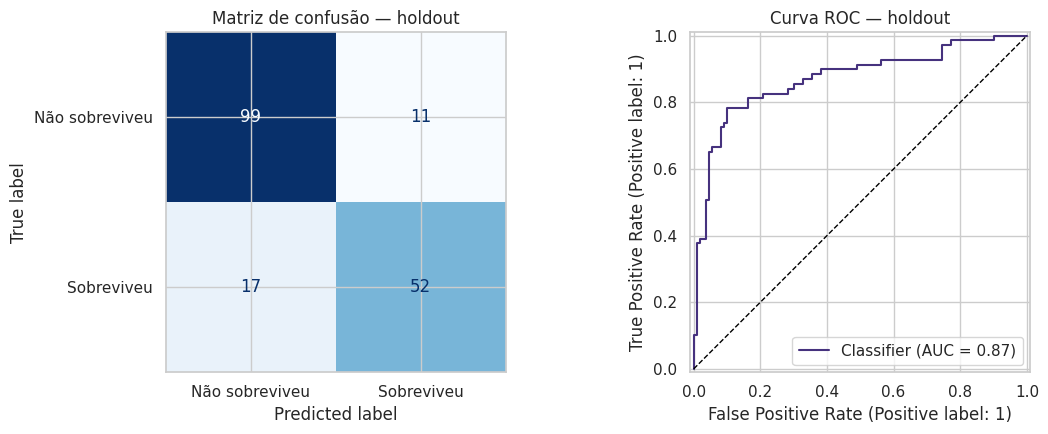

In [12]:
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, roc_auc_score)

melhor_modelo = grid.best_estimator_
y_pred = melhor_modelo.predict(X_val)
y_proba = melhor_modelo.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred, target_names=['Não sobreviveu', 'Sobreviveu']))
print(f'ROC AUC: {roc_auc_score(y_val, y_proba):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred, display_labels=['Não sobreviveu', 'Sobreviveu'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Matriz de confusão — holdout')
RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('Curva ROC — holdout')
plt.tight_layout()
plt.show()

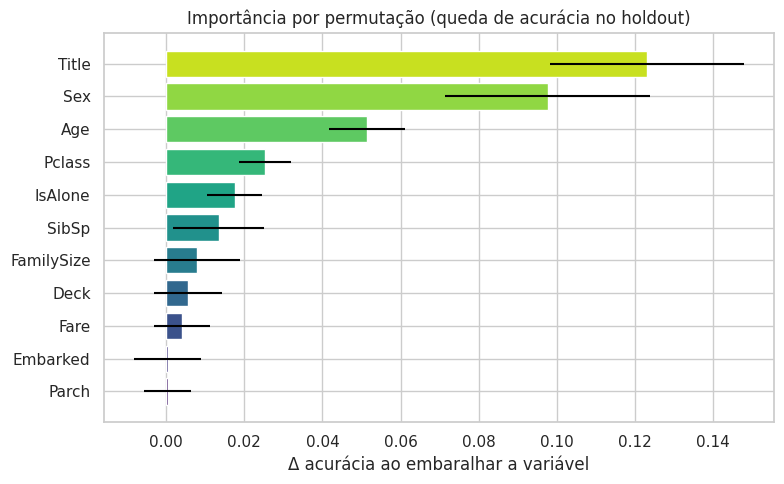

In [13]:
# Importância por permutação (nas colunas originais, direto no pipeline)
from sklearn.inspection import permutation_importance

perm = permutation_importance(melhor_modelo, X_val, y_val, n_repeats=15,
                              random_state=RANDOM_STATE, scoring='accuracy', n_jobs=-1)

imp = (pd.DataFrame({'feature': X_val.columns,
                     'importancia': perm.importances_mean,
                     'std': perm.importances_std})
       .sort_values('importancia'))

plt.figure(figsize=(8, 5))
plt.barh(imp['feature'], imp['importancia'], xerr=imp['std'], color=sns.color_palette('viridis', len(imp)))
plt.title('Importância por permutação (queda de acurácia no holdout)')
plt.xlabel('Δ acurácia ao embaralhar a variável')
plt.tight_layout()
plt.show()

A importância por permutação confirma a EDA: as variáveis ligadas a **sexo/título** dominam, seguidas de **classe** e **tarifa**. Vantagem dessa técnica sobre a importância nativa de árvores: é medida no holdout, sobre as colunas originais (pré-encoding), e é agnóstica ao modelo.

## 7. Submissão Kaggle

Reajusto o pipeline vencedor (com os hiperparâmetros do grid) em **100% do treino** e gero as predições para `test.csv` no formato oficial de submissão.

In [14]:
from sklearn.base import clone

modelo_final = clone(grid.best_estimator_).fit(X, y)

submission = pd.DataFrame({
    'PassengerId': test_fe['PassengerId'],
    'Survived': modelo_final.predict(test_fe[FEATURES]),
})
submission.to_csv('submission.csv', index=False)

print(f'submission.csv gerado — {len(submission)} predições')
print(f'Taxa de sobrevivência prevista no teste: {submission.Survived.mean():.1%}')
print('Baseline de referência (gender_submission = "toda mulher sobrevive"): ~0.7655 no leaderboard público')
submission.head()

submission.csv gerado — 418 predições
Taxa de sobrevivência prevista no teste: 40.2%
Baseline de referência (gender_submission = "toda mulher sobrevive"): ~0.7655 no leaderboard público


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 8. Bônus — Regressão com target assimétrico (técnicas do *House Prices — Ames*)

O dataset *Ames* (item 5 da lista) é o clássico de **regressão**: target contínuo com forte assimetria à direita, resolvido com transformação logarítmica. `Fare` tem exatamente esse perfil, então dá para demonstrar a mesma metodologia aqui:

1. Diagnóstico de assimetria (*skewness*) e transformação `log1p` do target;
2. `TransformedTargetRegressor` — treina no espaço log, devolve predições na escala original;
3. Comparação de um modelo linear regularizado (**Ridge**) vs. **boosting de gradiente**, com RMSE e R² em validação cruzada.

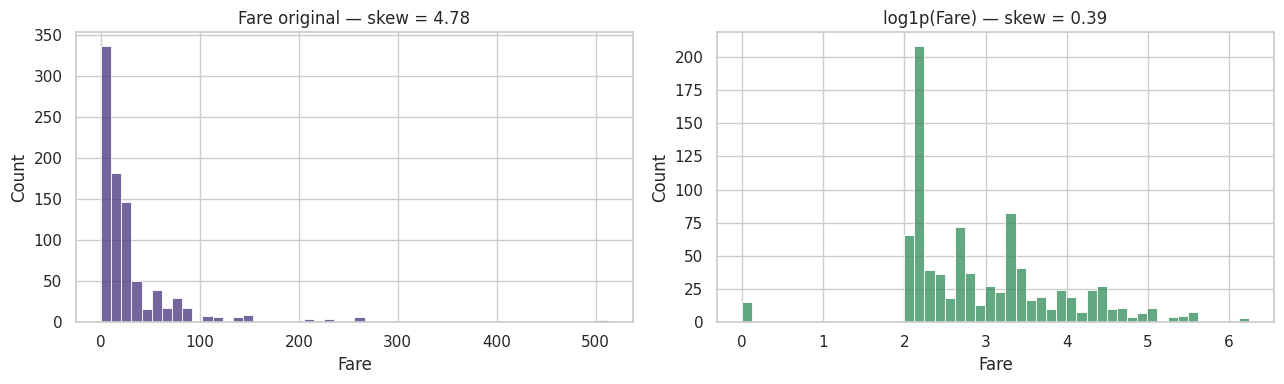

In [15]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(train_fe['Fare'], bins=50, ax=axes[0])
axes[0].set_title(f'Fare original — skew = {skew(train_fe.Fare.dropna()):.2f}')
sns.histplot(np.log1p(train_fe['Fare']), bins=50, ax=axes[1], color='seagreen')
axes[1].set_title(f'log1p(Fare) — skew = {skew(np.log1p(train_fe.Fare.dropna())):.2f}')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

FEATURES_NUM_REG = ['Age', 'SibSp', 'Parch', 'FamilySize', 'IsAlone']
FEATURES_CAT_REG = ['Pclass', 'Sex', 'Embarked', 'Title', 'Deck']
FEATURES_REG = FEATURES_NUM_REG + FEATURES_CAT_REG

X_reg = train_fe[FEATURES_REG]
y_reg = train_fe['Fare']

preproc_reg = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler', StandardScaler())]), FEATURES_NUM_REG),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), FEATURES_CAT_REG),
])

regressores = {
    'Ridge (target em log)': Ridge(alpha=1.0),
    'Hist. Gradient Boosting (target em log)': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

res_reg = []
for nome, reg in regressores.items():
    modelo = TransformedTargetRegressor(
        regressor=Pipeline([('preproc', preproc_reg), ('reg', reg)]),
        func=np.log1p, inverse_func=np.expm1,
    )
    cv = cross_validate(modelo, X_reg, y_reg, cv=kf,
                        scoring=['neg_root_mean_squared_error', 'r2'], n_jobs=-1)
    res_reg.append({
        'Modelo': nome,
        'RMSE (CV)': -cv['test_neg_root_mean_squared_error'].mean(),
        'R² (CV)': cv['test_r2'].mean(),
    })

res_reg = pd.DataFrame(res_reg).sort_values('RMSE (CV)').reset_index(drop=True)
res_reg.style.format({'RMSE (CV)': '£{:.2f}', 'R² (CV)': '{:.3f}'})

,Modelo,RMSE (CV),R² (CV)
0,Ridge (target em log),£32.78,0.559
1,Hist. Gradient Boosting (target em log),£34.35,0.506


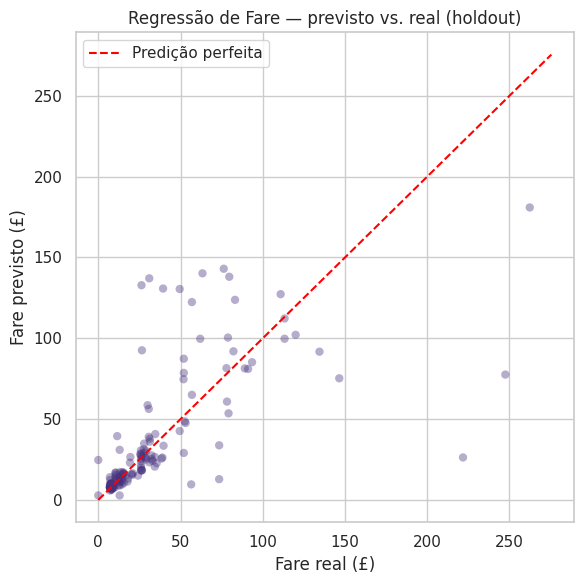

In [17]:
# Diagnóstico visual do melhor regressor: previsto vs. real
Xr_tr, Xr_val, yr_tr, yr_val = train_test_split(X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

melhor_reg = TransformedTargetRegressor(
    regressor=Pipeline([('preproc', preproc_reg),
                        ('reg', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
    func=np.log1p, inverse_func=np.expm1,
).fit(Xr_tr, yr_tr)

yr_pred = melhor_reg.predict(Xr_val)

plt.figure(figsize=(6, 6))
plt.scatter(yr_val, yr_pred, alpha=0.4, edgecolor='none')
lim = [0, max(yr_val.max(), yr_pred.max()) * 1.05]
plt.plot(lim, lim, 'r--', lw=1.5, label='Predição perfeita')
plt.xlabel('Fare real (£)')
plt.ylabel('Fare previsto (£)')
plt.title('Regressão de Fare — previsto vs. real (holdout)')
plt.legend()
plt.tight_layout()
plt.show()

O padrão é o mesmo do *Ames*: a transformação log estabiliza a variância e o boosting captura as não linearidades (classe × deck × família) melhor que o modelo linear. Os pontos extremos de tarifa (> £200) seguem difíceis — no *Ames* real, o passo seguinte seria feature engineering mais agressivo e ensembles.

## 9. Conclusões e próximos passos

**O que este notebook entrega:**

- EDA orientada a hipóteses, com achados que guiaram o feature engineering;
- Variáveis derivadas com sinal real (`Title`, `FamilySize`, `Deck`);
- Pipeline scikit-learn sem vazamento de dados, com comparação justa de 4 modelos, tuning e avaliação em holdout intocado;
- Interpretabilidade via importância por permutação;
- `submission.csv` pronto para o Kaggle;
- Bônus de regressão demonstrando o tratamento de target assimétrico (metodologia *House Prices — Ames*).

**Próximos passos naturais:**

1. Threshold tuning e calibração de probabilidades (`CalibratedClassifierCV`);
2. Ensemble/stacking dos melhores modelos;
3. Features de grupo por `Ticket` compartilhado (sobrevivência correlacionada dentro do grupo);
4. Replicar esta estrutura nos datasets **IBM HR Attrition** (classificação, People Analytics) e **Ames House Prices** (regressão completa).